# TraceWinEnv one-step debug

This notebook runs the smallest useful TraceWinEnv check:

1. verify that SSH to `comunian@localhost` is reachable;
2. instantiate `TraceWinEnv`;
3. call `reset()`;
4. call one `step()` with zero action;
5. print the simulator result, errors, score, and files written in `calc_dir`;
6. optionally render the episode and final phase-space distribution.

It is meant for debugging TraceWin itself, not for training or policy evaluation.

**Determinism note:** TraceWin runs **unseeded** here, like everywhere else in the
project except `beam_optimization/scripts/sensitivity.py` (which fixes
`tracewin_params["random_seed"]` for common-random-numbers variance reduction across
its finite-difference probes). This means TraceWin's own internal Monte Carlo particle
sampling is free to vary between runs of this notebook, so the transmitted particle
fraction and score can differ noticeably run to run even with identical machine
parameters — that's expected, not a bug. If you need a reproducible run for a specific
debugging session, you can still set `env.simulator.tracewin_params["random_seed"] = N`
manually before calling `reset()`/`step()`.
</cell id="39a55686">


In [1]:
from __future__ import annotations

import os
import subprocess
import sys
import traceback
import time
from pathlib import Path

import numpy as np


def find_repo_root(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if (candidate / "beam_optimization").is_dir():
            return candidate
    raise RuntimeError(f"Could not find repository root from {start}")


REPO_ROOT = find_repo_root(Path.cwd().resolve())
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib")

from beam_optimization.config.adige import default_params
from beam_optimization.config.paths import DEFAULT_TRACEWIN_INI
from beam_optimization.env.tracewin_env import TraceWinEnv

SEED = 123  # RL-level seed for env.reset(seed=...); does not affect TraceWin itself.
TIMEOUT_SECONDS = 25.0
RETRIES = 0

project_file = Path(DEFAULT_TRACEWIN_INI)
calc_dir = project_file.parent / "calc_debug_env"

print(f"repo_root    = {REPO_ROOT}")
print(f"project_file = {project_file}")
print(f"calc_dir     = {calc_dir}")


repo_root    = /mnt/meneghetti/FEDERICO_TESI/rl_beam_optimization
project_file = /mnt/meneghetti/FEDERICO_TESI/rl_beam_optimization/beam_optimization/env/tracewin_env/tracewin/TraceWin_workspace/CB_newMRMS_RFQ_Fields_1.ini
calc_dir     = /mnt/meneghetti/FEDERICO_TESI/rl_beam_optimization/beam_optimization/env/tracewin_env/tracewin/TraceWin_workspace/calc_debug_env


In [2]:
def list_calc_files(path: Path) -> None:
    if not path.exists():
        print(f"calc_dir does not exist: {path}")
        return
    files = sorted(p for p in path.iterdir() if p.is_file())
    if not files:
        print("calc_dir is empty")
        return
    for p in files:
        print(f"{p.name:<28} {p.stat().st_size:>12,} bytes")


def print_sim_result(label: str, info: dict) -> None:
    result = info.get("sim_result")
    print()
    print(f"[{label}]")
    print(f"score = {info.get('score')}")
    if result is None:
        print("sim_result missing")
        return
    print(f"success     = {result.success}")
    print(f"source      = {result.source}")
    print(f"score_val   = {result.score_val}")
    print(f"error       = {result.error}")
    print(f"beam_states = {None if result.beam_states is None else result.beam_states.shape}")
    print(f"metadata    = {result.metadata}")


In [3]:
# TraceWin is launched through SSH as comunian@localhost. Check that first.
ssh_cmd = [
    "ssh", "-F", "/dev/null",
    "-o", "BatchMode=yes",
    "-o", "ConnectTimeout=5",
    "comunian@localhost",
    "echo tracewin-ssh-ok",
]

try:
    ssh_check = subprocess.run(ssh_cmd, timeout=10, capture_output=True, text=True)
    print("returncode:", ssh_check.returncode)
    print("stdout:", ssh_check.stdout.strip())
    print("stderr:", ssh_check.stderr.strip())
except Exception:
    traceback.print_exc()


returncode: 0
stdout: tracewin-ssh-ok
stderr: 


In [4]:
# Instantiate TraceWinEnv. timeout and retries are intentionally small for this debug notebook.
env = TraceWinEnv(
    project_file=str(project_file),
    calc_dir=str(calc_dir),
    max_steps=1,
    timeout=TIMEOUT_SECONDS,
    retries=RETRIES,
)

print("env created")
print("observation_space:", env.observation_space)
print("action_space:", env.action_space)
print("simulator:", type(env.simulator).__name__)
print("simulator.calc_dir:", env.simulator.calc_dir)
print("simulator.tracewin_params:", env.simulator.tracewin_params)
print("simulator.num_threads:", env.simulator.num_threads)


env created
observation_space: Box(-inf, inf, (27,), float32)
action_space: Box([-7.32680e-06 -1.46212e-04 -1.79236e-06 -4.88880e-07 -1.57464e+01
 -4.76520e-09 -6.98040e-07 -1.42492e-01 -3.49524e-07 -1.74960e+00
 -3.75308e-03 -7.20000e-03 -1.94400e-01 -1.38688e-07 -1.67284e-01
 -4.13960e-06 -2.02964e-06 -5.09840e-01], [7.32680e-06 1.46212e-04 1.79236e-06 4.88880e-07 1.57464e+01 4.76520e-09
 6.98040e-07 1.42492e-01 3.49524e-07 1.74960e+00 3.75308e-03 7.20000e-03
 1.94400e-01 1.38688e-07 1.67284e-01 4.13960e-06 2.02964e-06 5.09840e-01], (18,), float32)
simulator: TraceWinSimulator
simulator.calc_dir: /mnt/meneghetti/FEDERICO_TESI/rl_beam_optimization/beam_optimization/env/tracewin_env/tracewin/TraceWin_workspace/calc_debug_env
simulator.tracewin_params: {}
simulator.num_threads: None


In [5]:
# Run reset(): this performs the first TraceWin simulation.
try:
    t0 = time.perf_counter()
    obs, info = env.reset(seed=SEED, options={"randomize_params": False})
    elapsed = time.perf_counter() - t0
    print(f"reset elapsed: {elapsed:.2f} s")
    print("obs.shape:", obs.shape)
    print("reset_randomized:", info.get("reset_randomized"))
    print("current_params == default_params():", env._current_params == default_params())
    print("current_params:", env._current_params)
    print_sim_result("reset", info)
except Exception:
    traceback.print_exc()

print()
print("calc_dir after reset:")
list_calc_files(calc_dir)


TraceWin execution failed with exit code 255
 
[BeamDataset] 4 samples loaded from /mnt/meneghetti/FEDERICO_TESI/rl_beam_optimization/beam_optimization/env/dataset/004/dataset_all.pt
reset elapsed: 3.58 s
obs.shape: (27,)
reset_randomized: False
current_params == default_params(): True
current_params: {'ele[2][5]': 0.43, 'ele[29][5]': 0.1, 'ele[38][1]': 0.0, 'ele[38][2]': 0.0, 'ele[151][2]': 0.0, 'ele[162][1]': 0.0, 'ele[162][2]': 0.0, 'ele[195][2]': 0.0, 'ele[197][5]': -0.0462087, 'ele[200][6]': 0.0, 'ele[201][6]': 0.0, 'ele[202][6]': 0.0, 'ele[203][6]': 0.0, 'ele[205][5]': 0.0462087, 'ele[225][2]': 0.0, 'ele[261][1]': 0.0, 'ele[261][2]': 0.0, 'ele[280][2]': -206.0}

[reset]
score = -999.0
success     = False
source      = tracewin
score_val   = -999.0
error       = TraceWin failed.
  stdout: 
  stderr: 
beam_states = None
metadata    = {'project_file': '/mnt/meneghetti/FEDERICO_TESI/rl_beam_optimization/beam_optimization/env/tracewin_env/tracewin/TraceWin_workspace/CB_newMRMS_RFQ_Fie

In [6]:
# Run exactly one step with zero action.
try:
    action = np.zeros(env.action_space.shape, dtype=np.float32)
    t0 = time.perf_counter()
    obs, reward, terminated, truncated, info = env.step(action)
    elapsed = time.perf_counter() - t0
    print(f"step elapsed: {elapsed:.2f} s")
    print("obs.shape:", obs.shape)
    print("reward:", reward)
    print("terminated:", terminated)
    print("truncated:", truncated)
    print_sim_result("step zero action", info)
except Exception:
    traceback.print_exc()

print()
print("calc_dir after step:")
list_calc_files(calc_dir)


step elapsed: 14.85 s
obs.shape: (27,)
reward: 1035.10366768
terminated: False
truncated: True

[step zero action]
score = 36.10366768
success     = True
source      = tracewin
score_val   = 36.10366768
error       = None
beam_states = (13, 9)
metadata    = {'project_file': '/mnt/meneghetti/FEDERICO_TESI/rl_beam_optimization/beam_optimization/env/tracewin_env/tracewin/TraceWin_workspace/CB_newMRMS_RFQ_Fields_1.ini', 'calc_dir': '/mnt/meneghetti/FEDERICO_TESI/rl_beam_optimization/beam_optimization/env/tracewin_env/tracewin/TraceWin_workspace/calc_debug_env', 'sim_count': 2, 'initial_npart': 10000}

calc_dir after step:
AD.BI.04.dst                      361,567 bytes
CB_newMRMS_RFQ_Fields_1.beta          353 bytes
CB_newMRMS_RFQ_Fields_1.dat         4,613 bytes
CB_newMRMS_RFQ_Fields_1.par        16,512 bytes
CB_newMRMS_RFQ_Fields_1_CC.txt        1,512 bytes
Cav_set_point_res.dat                 134 bytes
Density_Env.dat                 4,134,570 bytes
Density_PAR.dat                12,16

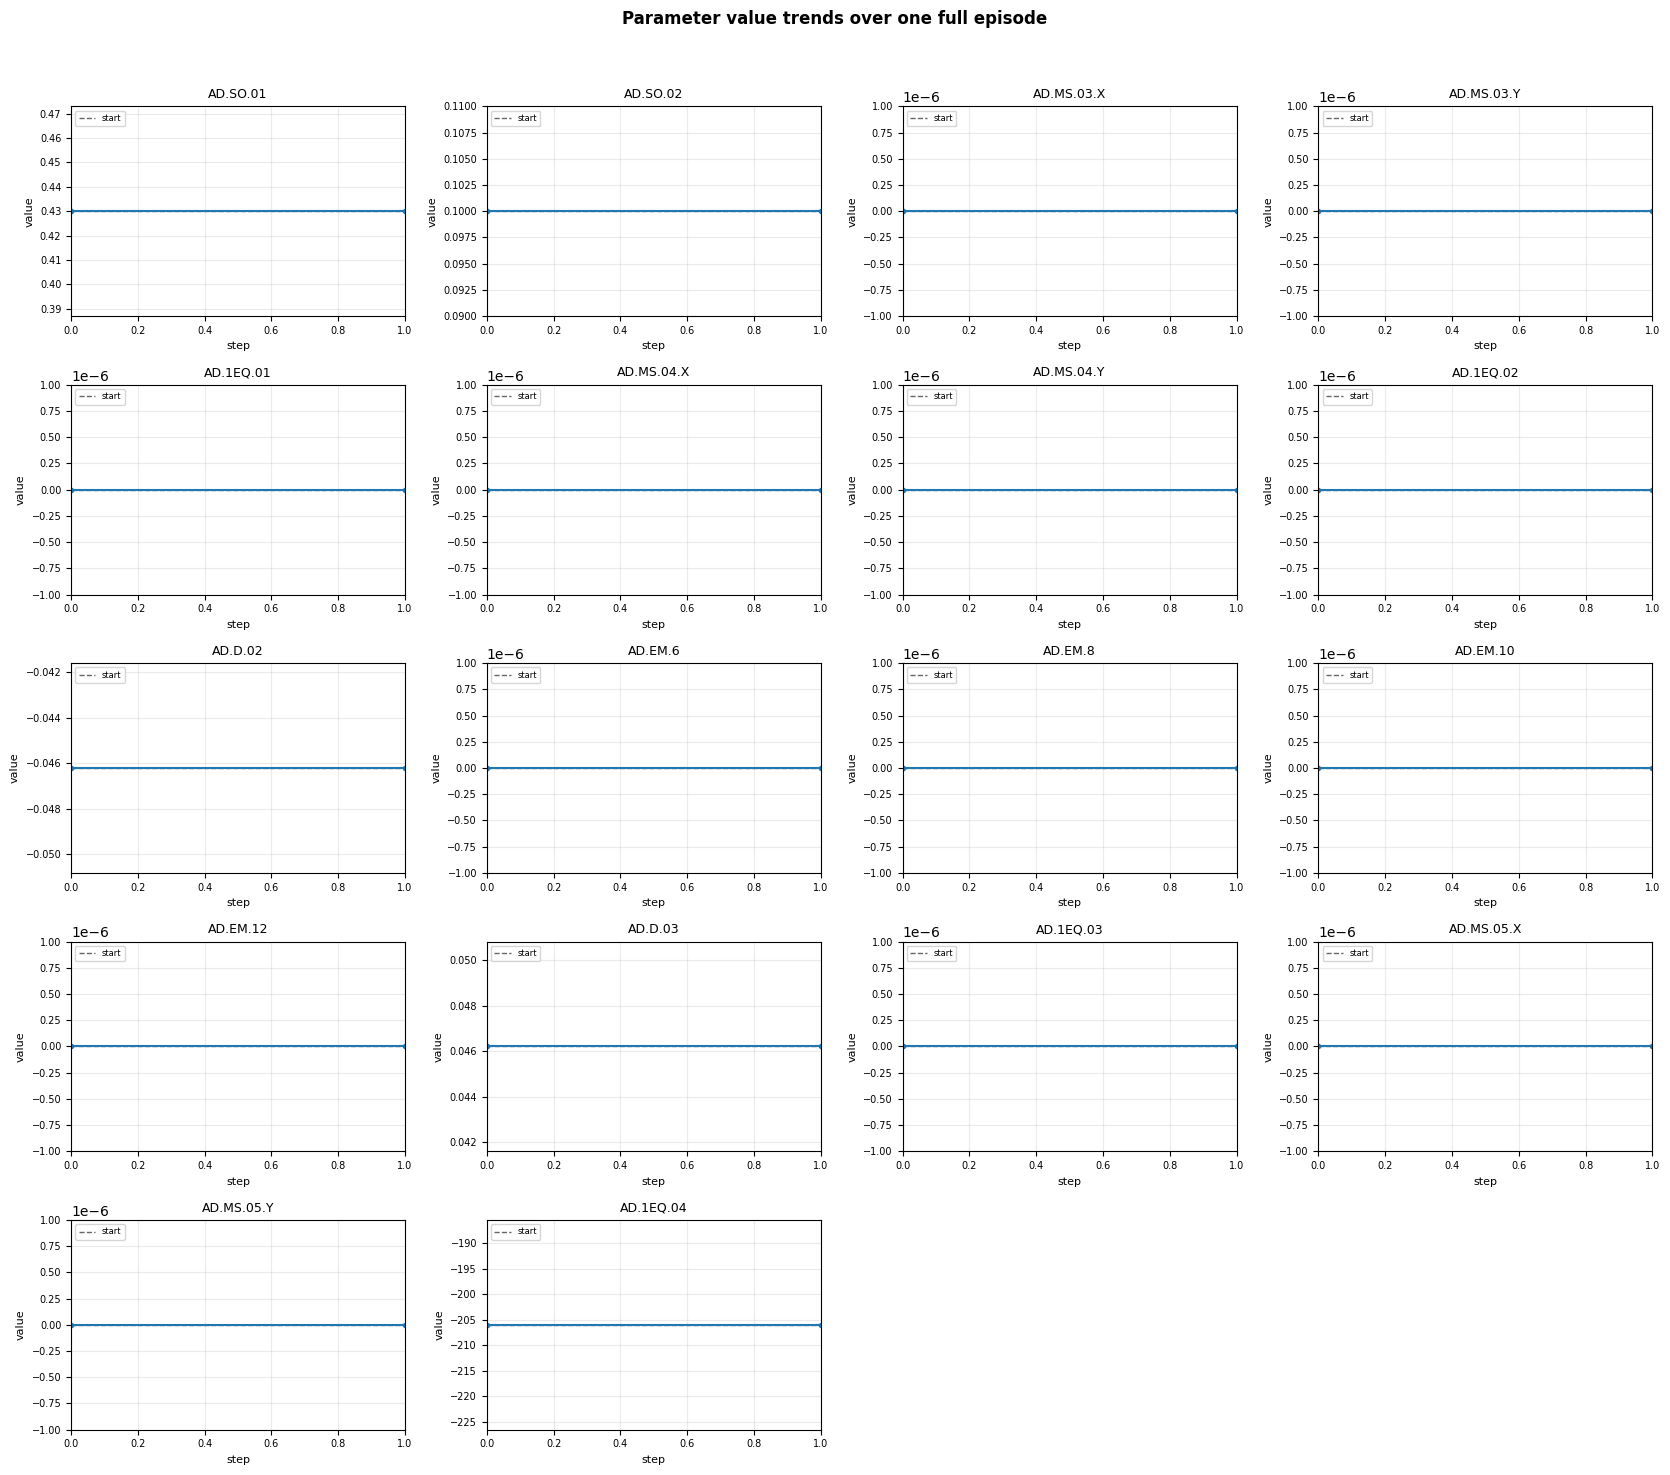

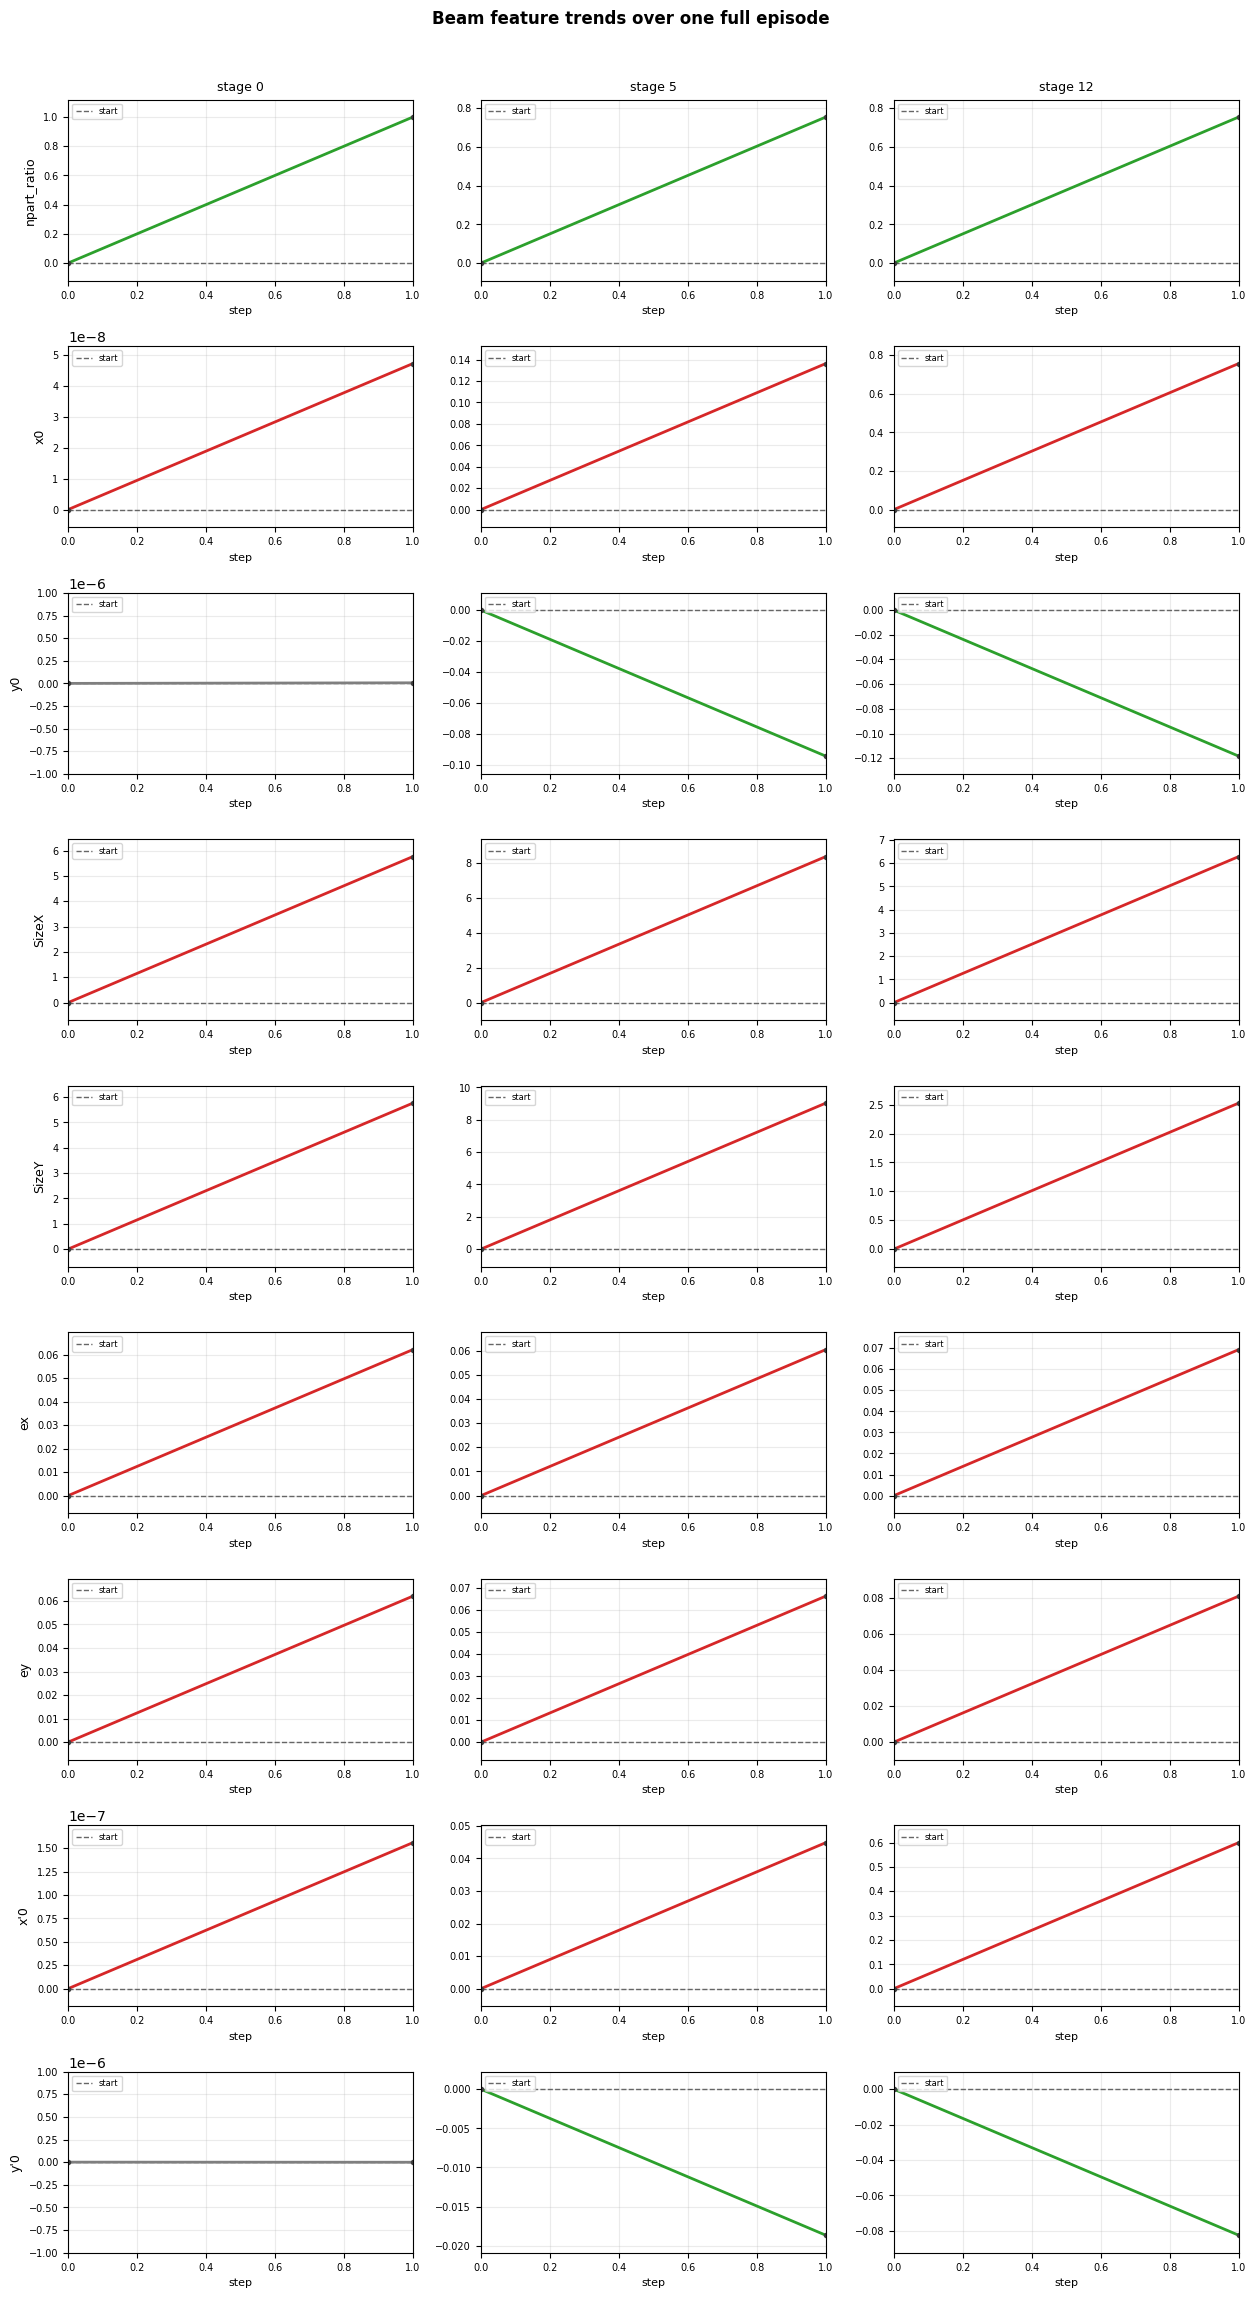

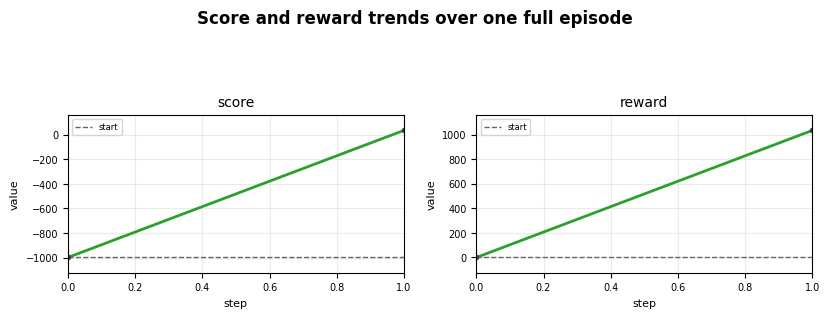

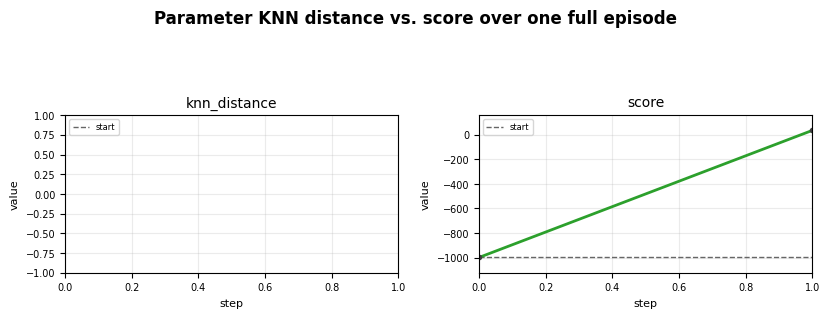

TraceWin final beam distribution render skipped: no final .dst file found in /mnt/meneghetti/FEDERICO_TESI/rl_beam_optimization/beam_optimization/env/tracewin_env/tracewin/TraceWin_workspace/calc_debug_env.


saved render files:
  params: /mnt/meneghetti/FEDERICO_TESI/rl_beam_optimization/beam_optimization/env/tracewin_env/tracewin/TraceWin_workspace/calc_debug_env/debug_render_params.png
  state: /mnt/meneghetti/FEDERICO_TESI/rl_beam_optimization/beam_optimization/env/tracewin_env/tracewin/TraceWin_workspace/calc_debug_env/debug_render_state.png
  score: /mnt/meneghetti/FEDERICO_TESI/rl_beam_optimization/beam_optimization/env/tracewin_env/tracewin/TraceWin_workspace/calc_debug_env/debug_render_score.png
  knn: /mnt/meneghetti/FEDERICO_TESI/rl_beam_optimization/beam_optimization/env/tracewin_env/tracewin/TraceWin_workspace/calc_debug_env/debug_render_knn.png


In [7]:
# Optional: render the episode trends and, if a .dst exists, the final beam distribution.
# The figures are saved as PNGs instead of printing the full Figure objects.
try:
    import matplotlib.pyplot as plt

    # Use TraceWinEnv's distribution defaults, shared with
    # visualize_distributions.ipynb: all particles, 200 bins,
    # +/-20 mm position zoom and +/-40 mrad angle zoom.
    render_result = env.render(render_beam_distribution=True)
    render_paths = {}

    for name, fig in render_result.items():
        if fig is None or not hasattr(fig, "savefig"):
            continue
        output_path = calc_dir / f"debug_render_{name}.png"
        fig.savefig(output_path, dpi=160, bbox_inches="tight")
        plt.close(fig)
        render_paths[name] = output_path

    if render_paths:
        print("saved render files:")
        for name, output_path in render_paths.items():
            print(f"  {name}: {output_path}")
    else:
        print("no render figures were produced")
except Exception:
    traceback.print_exc()
